In [7]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv(
    '/content/drive/MyDrive/part-00000-5d7d137c-d451-4b65-b9c2-3c3d0bbcd7f8-c000.csv',
    on_bad_lines='skip', low_memory=False
)

num_cols = ['review_stars', 'useful', 'funny', 'cool', 'word_count',
            'business_stars', 'review_count', 'is_open',
            'user_review_count', 'user_useful', 'user_funny', 'user_cool']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['yelping_since'] = pd.to_datetime(df['yelping_since'], errors='coerce')

print("Loaded. Shape:", df.shape)

Loaded. Shape: (569937, 25)


In [9]:
def label_fake(row):
    score = 0
    if row['user_review_count'] <= 2:                                    score += 2
    if row['review_stars'] in [1.0, 5.0]:                               score += 1
    if row['word_count'] <= 10:                                          score += 2
    if row['useful'] == 0 and row['funny'] == 0 and row['cool'] == 0:   score += 1
    if pd.notna(row['review_stars']) and pd.notna(row['business_stars']):
        if abs(row['review_stars'] - row['business_stars']) >= 2:        score += 1
    if row['user_useful'] == 0 and row['user_funny'] == 0 and row['user_cool'] == 0: score += 1
    return 1 if score >= 4 else 0

df['is_fake'] = df.apply(label_fake, axis=1)
print(df['is_fake'].value_counts())
print(f"Fake ratio: {df['is_fake'].mean():.2%}")

is_fake
0    523264
1     46673
Name: count, dtype: int64
Fake ratio: 8.19%


In [10]:
df = df[df['review_stars'].between(1, 5)]
df = df[df['business_stars'].between(1, 5)]
df = df[df['is_open'].isin([0, 1])]
df = df[df['word_count'] < 2000]
df = df.dropna(subset=['clean_text', 'is_fake'])

df['account_age_days']     = (df['date'] - df['yelping_since']).dt.days
df['star_vs_business_diff'] = abs(df['review_stars'] - df['business_stars'])
df['engagement_score']      = df['useful'] + df['funny'] + df['cool']
df['user_engagement_score'] = df['user_useful'] + df['user_funny'] + df['user_cool']

print("Clean shape:", df.shape)
print(df['is_fake'].value_counts())

Clean shape: (453215, 30)
is_fake
0    409636
1     43579
Name: count, dtype: int64


In [11]:
df = df.groupby('is_fake', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50000), random_state=42)
).reset_index(drop=True)

print("Sampled shape:", df.shape)
print(df['is_fake'].value_counts())

/tmp/ipykernel_4444/487637339.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('is_fake', group_keys=False).apply(


Sampled shape: (93579, 30)
is_fake
0    50000
1    43579
Name: count, dtype: int64


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)
X_text = tfidf.fit_transform(df['clean_text'].fillna(''))

clean_tabular_cols = [
    'business_stars',
    'review_count',
    'is_open',
    'account_age_days',
]

X_tab = csr_matrix(df[clean_tabular_cols].fillna(0).values)
X_combined = hstack([X_text, X_tab])
y = df['is_fake'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (74863, 50004) | Test: (18716, 50004)


In [18]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    max_depth=-1, n_jobs=-1, random_state=42, verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.54596
[100]	valid_0's binary_logloss: 0.521645
[150]	valid_0's binary_logloss: 0.513257
[200]	valid_0's binary_logloss: 0.510384
[250]	valid_0's binary_logloss: 0.509318
[300]	valid_0's binary_logloss: 0.509125
[350]	valid_0's binary_logloss: 0.508689
[400]	valid_0's binary_logloss: 0.50874
Early stopping, best iteration is:
[365]	valid_0's binary_logloss: 0.508635


LGBMClassifier(learning_rate=0.05, n_estimators=500, n_jobs=-1, num_leaves=63,
               random_state=42, verbose=-1)

In [19]:
from sklearn.metrics import classification_report, roc_auc_score

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("LightGBM Report")
print(classification_report(y_test, preds))
print(f"AUC: {roc_auc_score(y_test, probs):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Report
              precision    recall  f1-score   support

           0       0.76      0.77      0.76     10000
           1       0.73      0.72      0.72      8716

    accuracy                           0.74     18716
   macro avg       0.74      0.74      0.74     18716
weighted avg       0.74      0.74      0.74     18716

AUC: 0.8270


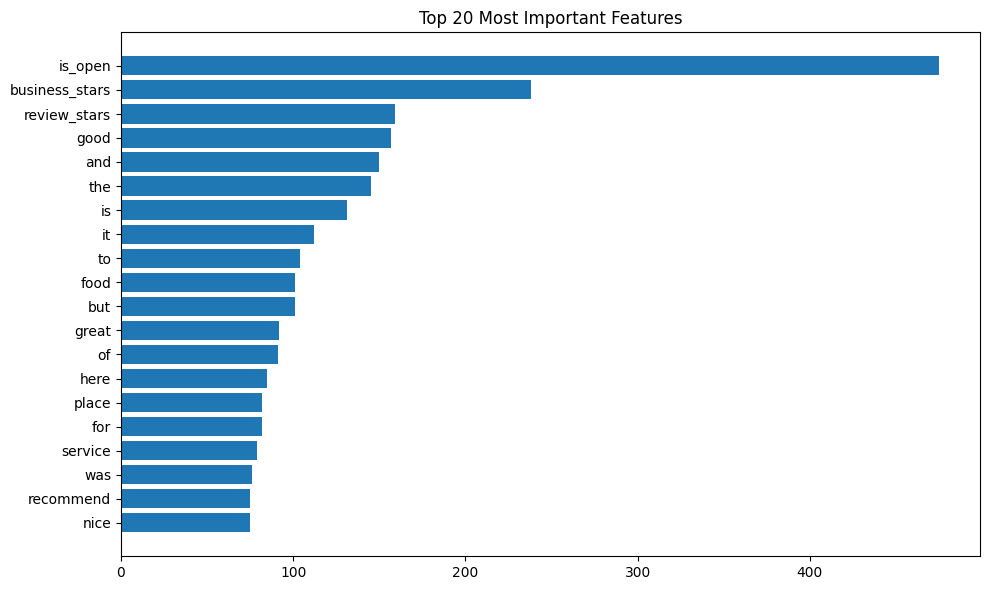

In [20]:
import matplotlib.pyplot as plt

all_features = tfidf.get_feature_names_out().tolist() + tabular_cols
importance = model.feature_importances_
indices = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.barh([all_features[i] for i in indices][::-1], importance[indices][::-1])
plt.title("Top 20 Most Important Features")
plt.tight_layout()
plt.show()

In [21]:
import pickle

with open('/content/drive/MyDrive/lgbm_fake_review_model_no.pkl', 'wb') as f:
    pickle.dump(model, f)

pd.DataFrame(classification_report(y_test, preds, output_dict=True)).to_csv(
    '/content/drive/MyDrive/lgbm_results_no.csv'
)
print("Saved to Google Drive!")

Saved to Google Drive!
